In [1]:
import os
import numpy as np
import ctypes
from ctypes import POINTER, c_double, c_int64, c_void_p, c_bool
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Load the DLL
mlp_lib = ctypes.CDLL("../library/MLP/mlp_save.dll")

# Define types for the functions
create_mlp = mlp_lib.create_mlp
create_mlp.argtypes = [POINTER(c_int64), c_int64]
create_mlp.restype = c_void_p

destroy_mlp = mlp_lib.mlp_free
destroy_mlp.argtypes = [c_void_p]
destroy_mlp.restype = None

train_mlp = mlp_lib.train_mlp
train_mlp.argtypes = [c_void_p, POINTER(c_double), c_int64, c_int64, POINTER(c_double), c_int64, c_double, c_int64, c_bool]
train_mlp.restype = None

predict_mlp = mlp_lib.mlp_predict
predict_mlp.argtypes = [c_void_p, POINTER(c_double), c_int64, c_int64, c_bool]
predict_mlp.restype = POINTER(c_double)

get_loss_values = mlp_lib.get_loss_values
get_loss_values.argtypes = [c_void_p, POINTER(c_int64)]
get_loss_values.restype = POINTER(c_double)

save_mlp = mlp_lib.save_mlp
save_mlp.argtypes = [c_void_p, ctypes.c_char_p]
save_mlp.restype = None

load_mlp = mlp_lib.load_mlp
load_mlp.argtypes = [c_void_p, ctypes.c_char_p]
load_mlp.restype = None


# Cas de test Classification 
## Linear Simple

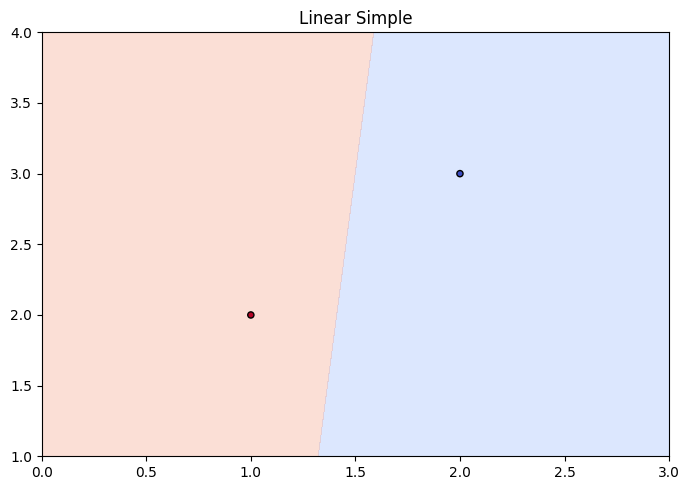

In [8]:
X1 = np.array([[1, 2], [2, 3]])
y1 = np.array([[0, 1], [0, -1]])

mlp_params = [2, 2]  

npl = np.array(mlp_params, dtype=c_int64)
npl_ctypes = npl.ctypes.data_as(POINTER(c_int64))

mlp = create_mlp(npl_ctypes, len(mlp_params))


X_flat = X1.flatten().astype(np.float64)
y_flat = y1.flatten().astype(np.float64)
X_ctypes = X_flat.ctypes.data_as(POINTER(c_double))
y_ctypes = y_flat.ctypes.data_as(POINTER(c_double))


train_mlp(mlp, X_ctypes, X1.shape[0], X1.shape[1], y_ctypes, y1.shape[1], 0.01, 10000, True)

def plot_decision_boundary(mlp, X, y, title, ax, is_classification):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
    grid = np.c_[xx.ravel(), yy.ravel()]
    zz = np.zeros(grid.shape[0])

    for i, (gx, gy) in enumerate(grid):
        inputs = np.array([gx, gy], dtype=np.float64)
        inputs_ctypes = inputs.ctypes.data_as(POINTER(c_double))
        pred = predict_mlp(mlp, inputs_ctypes, 1, len(inputs), is_classification)
        zz[i] = pred[1]  # Use the second output as the decision boundary

    zz = zz.reshape(xx.shape)
    ax.contourf(xx, yy, zz, levels=[-1, 0, 1], alpha=0.3, cmap='coolwarm')  # Add levels to make a clear separation

    y_colors = np.argmax(y, axis=1)  # Use the index of the maximum value as color code
    ax.scatter(X[:, 0], X[:, 1], c=y_colors, s=20, edgecolor='k', cmap=plt.cm.coolwarm)

fig, ax = plt.subplots(figsize=(7, 5))
plot_decision_boundary(mlp, X1, y1, 'Linear Simple', ax, True)
ax.set_title('Linear Simple')

destroy_mlp(mlp)

plt.tight_layout()
plt.show()

## Linear Multiple

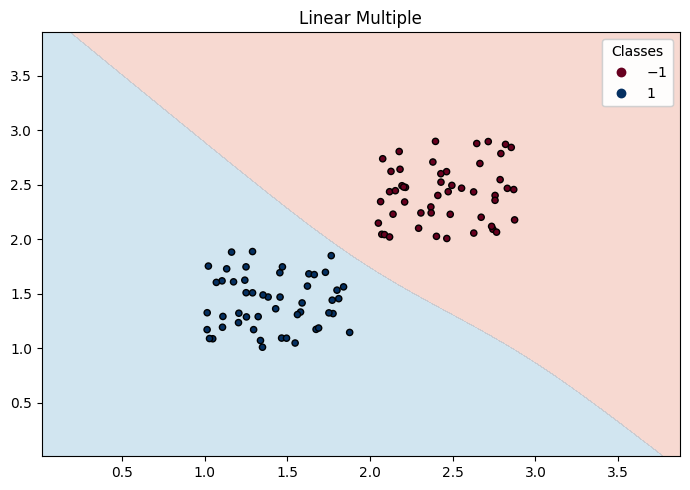

In [3]:
def run_linear_multiple():
    X = np.concatenate([np.random.random((50, 2)) * 0.9 + np.array([1, 1]),
                        np.random.random((50, 2)) * 0.9 + np.array([2, 2])])
    Y = np.concatenate([np.ones((50, 1)), np.ones((50, 1)) * -1.0])
    
    layers = [X.shape[1], 5, Y.shape[1]]
    mlp_params = np.array(layers, dtype=c_int64)
    mlp_params_ctypes = mlp_params.ctypes.data_as(POINTER(c_int64))
    
    mlp = create_mlp(mlp_params_ctypes, len(layers))
    
    X_flat = X.flatten().astype(np.float64)
    Y_flat = Y.flatten().astype(np.float64)
    X_ctypes = X_flat.ctypes.data_as(POINTER(c_double))
    Y_ctypes = Y_flat.ctypes.data_as(POINTER(c_double))
    
    train_mlp(mlp, X_ctypes, X.shape[0], X.shape[1], Y_ctypes, Y.shape[1], 0.1, 5000, True)
    
    def plot_decision_boundary(mlp, X, y, ax, is_classification):
        x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
        xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
        grid = np.c_[xx.ravel(), yy.ravel()]
        zz = np.zeros(grid.shape[0])

        for i, (gx, gy) in enumerate(grid):
            inputs = np.array([gx, gy], dtype=np.float64)
            inputs_ctypes = inputs.ctypes.data_as(POINTER(c_double))
            pred = predict_mlp(mlp, inputs_ctypes, 1, len(inputs), is_classification)
            zz[i] = pred[0]  

        zz = zz.reshape(xx.shape)
        ax.contourf(xx, yy, zz, levels=[-1, 0, 1], alpha=0.3, cmap=plt.cm.RdBu)

        y_colors = y.flatten()  
        scatter = ax.scatter(X[:, 0], X[:, 1], c=y_colors, s=20, edgecolor='k', cmap=plt.cm.RdBu)
        legend1 = ax.legend(*scatter.legend_elements(), loc="upper right", title="Classes")
        ax.add_artist(legend1)
    
    fig, ax = plt.subplots(figsize=(7, 5))
    plot_decision_boundary(mlp, X, Y, ax, True)
    ax.set_title('Linear Multiple')
    
    destroy_mlp(mlp)
    
    plt.tight_layout()
    plt.show()

run_linear_multiple()


## XOR

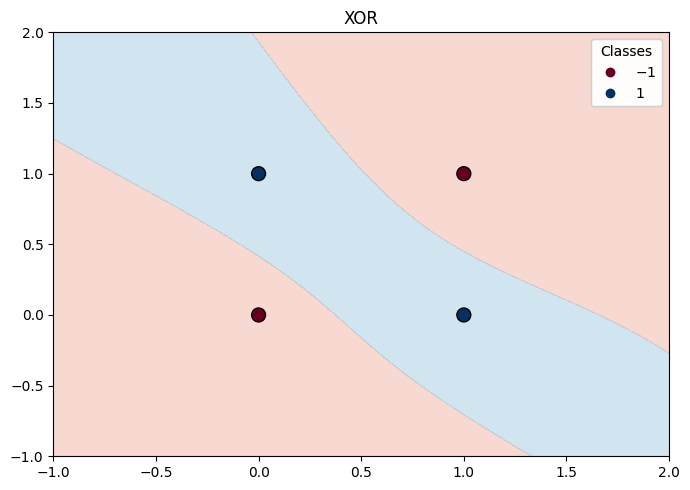

In [4]:
def run_xor():
    X = np.array([[1, 0], [0, 1], [0, 0], [1, 1]])
    Y = np.array([1, 1, -1, -1]).reshape(-1, 1)
    
    layers = [X.shape[1], 5, Y.shape[1]]
    mlp_params = np.array(layers, dtype=c_int64)
    mlp_params_ctypes = mlp_params.ctypes.data_as(POINTER(c_int64))
    
    mlp = create_mlp(mlp_params_ctypes, len(layers))
    
    X_flat = X.flatten().astype(np.float64)
    Y_flat = Y.flatten().astype(np.float64)
    X_ctypes = X_flat.ctypes.data_as(POINTER(c_double))
    Y_ctypes = Y_flat.ctypes.data_as(POINTER(c_double))
    
    train_mlp(mlp, X_ctypes, X.shape[0], X.shape[1], Y_ctypes, Y.shape[1], 0.1, 10000, True)
    
    def plot_decision_boundary(mlp, X, y, ax, is_classification):
        x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
        xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
        grid = np.c_[xx.ravel(), yy.ravel()]
        zz = np.zeros(grid.shape[0])

        for i, (gx, gy) in enumerate(grid):
            inputs = np.array([gx, gy], dtype=np.float64)
            inputs_ctypes = inputs.ctypes.data_as(POINTER(c_double))
            pred = predict_mlp(mlp, inputs_ctypes, 1, len(inputs), is_classification)
            zz[i] = pred[0]  # Use the first output for decision boundary

        zz = zz.reshape(xx.shape)
        ax.contourf(xx, yy, zz, levels=[-1, 0, 1], alpha=0.3, cmap=plt.cm.RdBu)

        y_colors = y.flatten()  # Use the actual labels for coloring
        scatter = ax.scatter(X[:, 0], X[:, 1], c=y_colors, s=100, edgecolor='k', cmap=plt.cm.RdBu)
        legend1 = ax.legend(*scatter.legend_elements(), loc="upper right", title="Classes")
        ax.add_artist(legend1)
    
    fig, ax = plt.subplots(figsize=(7, 5))
    plot_decision_boundary(mlp, X, Y, ax, True)
    ax.set_title('XOR')
    
    destroy_mlp(mlp)
    
    plt.tight_layout()
    plt.show()

run_xor()

## Cross

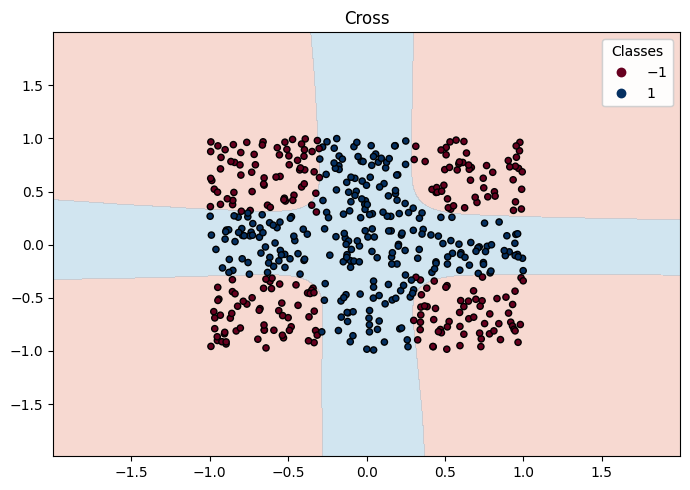

In [5]:
def run_cross():
    X = np.random.random((500, 2)) * 2.0 - 1.0
    Y = np.array([1 if abs(p[0]) <= 0.3 or abs(p[1]) <= 0.3 else -1 for p in X]).reshape(-1, 1)
    
    layers = [X.shape[1], 8, Y.shape[1]]
    mlp_params = np.array(layers, dtype=c_int64)
    mlp_params_ctypes = mlp_params.ctypes.data_as(POINTER(c_int64))
    
    mlp = create_mlp(mlp_params_ctypes, len(layers))
    
    X_flat = X.flatten().astype(np.float64)
    Y_flat = Y.flatten().astype(np.float64)
    X_ctypes = X_flat.ctypes.data_as(POINTER(c_double))
    Y_ctypes = Y_flat.ctypes.data_as(POINTER(c_double))
    
    train_mlp(mlp, X_ctypes, X.shape[0], X.shape[1], Y_ctypes, Y.shape[1], 0.01, 100000, True)
    
    def plot_decision_boundary(mlp, X, y, ax, is_classification):
        x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
        xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
        grid = np.c_[xx.ravel(), yy.ravel()]
        zz = np.zeros(grid.shape[0])

        for i, (gx, gy) in enumerate(grid):
            inputs = np.array([gx, gy], dtype=np.float64)
            inputs_ctypes = inputs.ctypes.data_as(POINTER(c_double))
            pred = predict_mlp(mlp, inputs_ctypes, 1, len(inputs), is_classification)
            zz[i] = pred[0]  
        zz = zz.reshape(xx.shape)
        ax.contourf(xx, yy, zz, levels=[-1, 0, 1], alpha=0.3, cmap=plt.cm.RdBu)

        y_colors = y.flatten()  
        scatter = ax.scatter(X[:, 0], X[:, 1], c=y_colors, s=20, edgecolor='k', cmap=plt.cm.RdBu)
        legend1 = ax.legend(*scatter.legend_elements(), loc="upper right", title="Classes")
        ax.add_artist(legend1)
    
    fig, ax = plt.subplots(figsize=(7, 5))
    plot_decision_boundary(mlp, X, Y, ax, True)
    ax.set_title('Cross')
    
    destroy_mlp(mlp)
    
    plt.tight_layout()
    plt.show()

run_cross()

## Multi Linear 3 classes

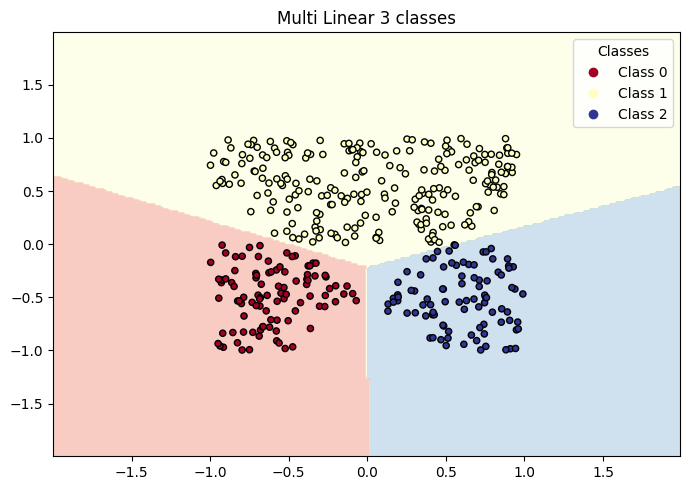

In [6]:
def test_Multi_Linaire(inputs, outputs, layers, title, output_dim, iteration_count, alpha, is_classification):
    mlp_params = np.array(layers, dtype=c_int64)
    mlp_params_ctypes = mlp_params.ctypes.data_as(POINTER(c_int64))
    
    mlp = create_mlp(mlp_params_ctypes, len(layers))
    
    inputs_flat = inputs.flatten().astype(np.float64)
    outputs_flat = outputs.flatten().astype(np.float64)
    inputs_ctypes = inputs_flat.ctypes.data_as(POINTER(c_double))
    outputs_ctypes = outputs_flat.ctypes.data_as(POINTER(c_double))
    
    train_mlp(mlp, inputs_ctypes, inputs.shape[0], inputs.shape[1], outputs_ctypes, output_dim, alpha, iteration_count, is_classification)
    
    def plot_decision_boundary(mlp, X, y, ax, is_classification):
        x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
        xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
        grid = np.c_[xx.ravel(), yy.ravel()]
        zz = np.zeros((grid.shape[0], y.shape[1]))

        for i, (gx, gy) in enumerate(grid):
            inputs = np.array([gx, gy], dtype=np.float64)
            inputs_ctypes = inputs.ctypes.data_as(POINTER(c_double))
            pred = predict_mlp(mlp, inputs_ctypes, 1, len(inputs), is_classification)
            zz[i] = np.ctypeslib.as_array(pred, shape=(y.shape[1],))

        zz = np.argmax(zz, axis=1).reshape(xx.shape)
        ax.contourf(xx, yy, zz, levels=np.arange(4) - 0.5, alpha=0.3, cmap=plt.cm.RdYlBu)

        y_colors = np.argmax(y, axis=1)  # Use the index of the maximum value as color code
        scatter = ax.scatter(X[:, 0], X[:, 1], c=y_colors, s=20, edgecolor='k', cmap=plt.cm.RdYlBu)
        handles, labels = scatter.legend_elements(prop="colors")
        labels = ["Class 0", "Class 1", "Class 2"]
        ax.legend(handles, labels, loc="upper right", title="Classes")

    fig, ax = plt.subplots(figsize=(7, 5))
    plot_decision_boundary(mlp, inputs, outputs, ax, is_classification)
    ax.set_title(title)
    
    destroy_mlp(mlp)
    
    plt.tight_layout()
    plt.show()

iteration_count = 100000
alpha = 0.01
inputs = np.random.random((500, 2)) * 2.0 - 1.0
outputs = np.array([[1, -1, -1] if -p[0] - p[1] - 0.5 > 0 and p[1] < 0 and p[0] - p[1] - 0.5 < 0 else
                    [-1, 1, -1] if -p[0] - p[1] - 0.5 < 0 and p[1] > 0 and p[0] - p[1] - 0.5 < 0 else
                    [-1, -1, 1] if -p[0] - p[1] - 0.5 < 0 and p[1] < 0 and p[0] - p[1] - 0.5 > 0 else
                    [0, 0, 0] for p in inputs], dtype=np.float64)

inputs = inputs[[not np.all(arr == [0, 0, 0]) for arr in outputs]]
outputs = outputs[[not np.all(arr == [0, 0, 0]) for arr in outputs]]

test_Multi_Linaire(inputs, outputs, [2, 3], "Multi Linear 3 classes", 3, iteration_count, alpha, True)

## Multi Cross

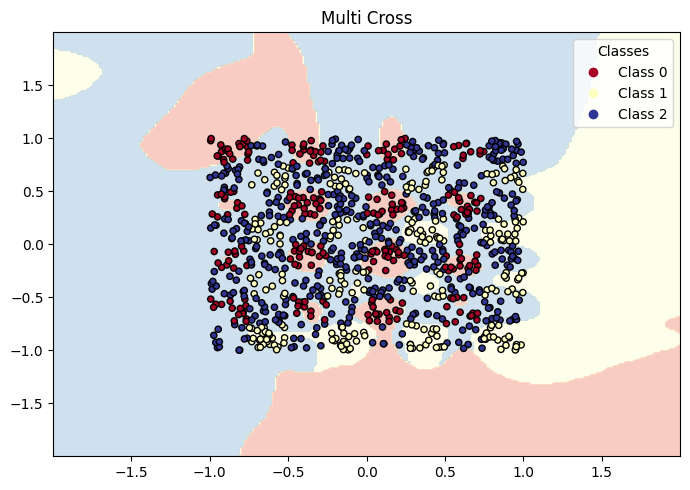

In [7]:
import numpy as np
import ctypes
from ctypes import POINTER, c_double, c_int64, c_void_p, c_bool
import matplotlib.pyplot as plt

# Charger la DLL
mlp_lib = ctypes.CDLL("../library/MLP/mlp_save.dll")

# Définir les types pour les fonctions
create_mlp = mlp_lib.create_mlp
create_mlp.argtypes = [POINTER(c_int64), c_int64]
create_mlp.restype = c_void_p

destroy_mlp = mlp_lib.mlp_free
destroy_mlp.argtypes = [c_void_p]
destroy_mlp.restype = None

train_mlp = mlp_lib.train_mlp
train_mlp.argtypes = [c_void_p, POINTER(c_double), c_int64, c_int64, POINTER(c_double), c_int64, c_double, c_int64, c_bool]
train_mlp.restype = None

predict_mlp = mlp_lib.mlp_predict
predict_mlp.argtypes = [c_void_p, POINTER(c_double), c_int64, c_int64, c_bool]
predict_mlp.restype = POINTER(c_double)

def plot_decision_boundary(mlp, X, y, ax, is_classification):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]
    zz = np.zeros((grid.shape[0], y.shape[1]))

    for i, (gx, gy) in enumerate(grid):
        inputs = np.array([gx, gy], dtype=np.float64)
        inputs_ctypes = inputs.ctypes.data_as(POINTER(c_double))
        pred = predict_mlp(mlp, inputs_ctypes, 1, len(inputs), is_classification)
        zz[i] = np.ctypeslib.as_array(pred, shape=(y.shape[1],))

    zz = np.argmax(zz, axis=1).reshape(xx.shape)
    ax.contourf(xx, yy, zz, levels=np.arange(4) - 0.5, alpha=0.3, cmap=plt.cm.RdYlBu)

    y_colors = np.argmax(y, axis=1)  
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y_colors, s=20, edgecolor='k', cmap=plt.cm.RdYlBu)
    handles, labels = scatter.legend_elements(prop="colors")
    labels = ["Class 0", "Class 1", "Class 2"]
    ax.legend(handles, labels, loc="upper right", title="Classes")

# Fonction de test pour Multi Cross
def run_multi_cross():
    X = np.random.random((1000, 2)) * 2.0 - 1.0
    Y = np.array([[1, 0, 0] if abs(p[0] % 0.5) <= 0.25 and abs(p[1] % 0.5) > 0.25 
                  else [0, 1, 0] if abs(p[0] % 0.5) > 0.25 and abs(p[1] % 0.5) <= 0.25 
                  else [0, 0, 1] for p in X])
    
    layers = [2, 100,50, 3]  
    mlp_params = np.array(layers, dtype=c_int64)
    mlp_params_ctypes = mlp_params.ctypes.data_as(POINTER(c_int64))
    
    mlp = create_mlp(mlp_params_ctypes, len(layers))
    
    X_flat = X.flatten().astype(np.float64)
    Y_flat = Y.flatten().astype(np.float64)
    X_ctypes = X_flat.ctypes.data_as(POINTER(c_double))
    Y_ctypes = Y_flat.ctypes.data_as(POINTER(c_double))
    
    train_mlp(mlp, X_ctypes, X.shape[0], X.shape[1], Y_ctypes, Y.shape[1], 0.01, 200000, True)
    
    fig, ax = plt.subplots(figsize=(7, 5))
    plot_decision_boundary(mlp, X, Y, ax, True)
    ax.set_title('Multi Cross')

    destroy_mlp(mlp)
    
    plt.tight_layout()
    plt.show()
run_multi_cross()


# Préparer le dataset

In [16]:
import numpy as np
from sklearn.model_selection import train_test_split
from ctypes import c_double

def prepare_flower_data():
    # Load vectors from files
    marguerite_vectors = np.load("../src/vector_data/marguerite_fleur_vectors.npy")
    rose_vectors = np.load("../src/vector_data/rose_rouge_vectors.npy")
    tulipe_vectors = np.load("../src/vector_data/tulipe_jaune_vectors.npy")

    # Create labels for classes
    marguerite_labels = np.array([[1.0, 0.0, 0.0]] * len(marguerite_vectors))
    rose_labels = np.array([[0.0, 1.0, 0.0]] * len(rose_vectors))
    tulipe_labels = np.array([[0.0, 0.0, 1.0]] * len(tulipe_vectors))

    # Combine the data and labels
    X = np.concatenate((marguerite_vectors, rose_vectors, tulipe_vectors))
    y = np.concatenate((marguerite_labels, rose_labels, tulipe_labels))

    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Flatten and convert training and testing data to c_double arrays
    train_data = (c_double * X_train.size)(*X_train.flatten())
    test_data = (c_double * X_test.size)(*X_test.flatten())
    train_labels = (c_double * y_train.size)(*y_train.flatten())
    print(f"Number of training points: {len(X_train)}")
    print(f"Number of test points: {len(X_test)}")

    return train_data, test_data, train_labels, X_train, X_test, y_train, y_test

# Function to plot the loss curve


In [8]:
import matplotlib.pyplot as plt
def plot_loss_curve(mlp_instance):
    length = c_int64()
    loss_ptr = get_loss_values(mlp_instance, ctypes.byref(length))
    if loss_ptr:
        loss_array = np.ctypeslib.as_array(loss_ptr, shape=(length.value,))
        plt.figure(figsize=(10, 6))
        plt.plot(loss_array, label='Loss')
        plt.xlabel('Iterations (x20000)')
        plt.ylabel('Loss')
        plt.title('Loss Curve')
        plt.legend()    
        plt.show()
        mlp_lib.mlp_free(loss_ptr)
    else:
        print("Error retrieving loss values")

# Avec environ 690 images par classe, une couche caché de 10 neurones et 10000 iteration et alpha = 0,1

Number of training points: 1655
Number of test points: 414
MLP network created with : 
9408 10 3 Alpha :  0.1
MLP network trained
Train accuracy: 0.35
Test accuracy: 0.32


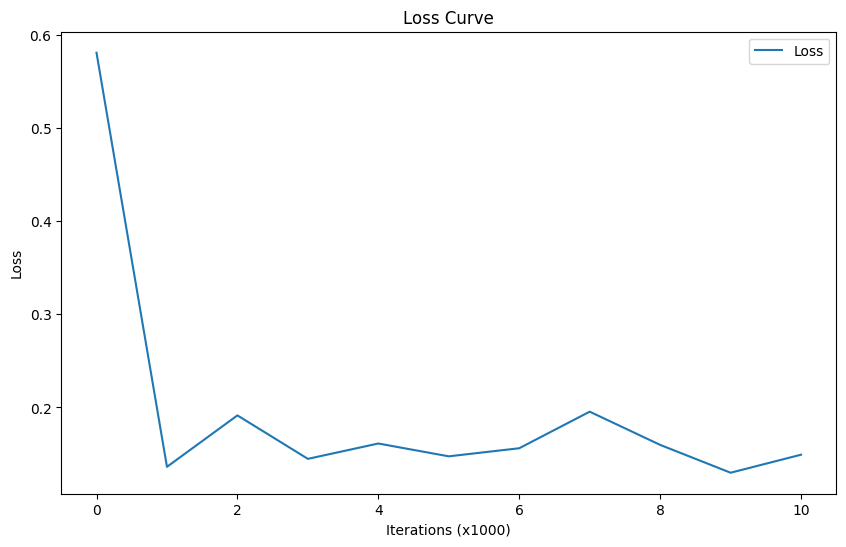

In [34]:
# Define the structure of the MLP
train_data, test_data, train_labels, X_train, X_test, y_train, y_test = prepare_flower_data()

layers = (c_int64 * 3)(X_train.shape[1],10, 3)  # Example structure with one hidden layer of 10 neurons
mlp_instance = create_mlp(layers, len(layers))
alpha =0.1
print("MLP network created with : ")
for i in range(len(layers)):
    print(layers[i],end=" ")
print("Alpha : ", alpha)

# Train the MLP network
try:
    train_mlp(mlp_instance, train_data, len(X_train), X_train.shape[1], train_labels, y_train.shape[1], alpha, 10000, True)
except Exception as e:
    print("Error during training:", e)

print("MLP network trained")

# Predict using the MLP network
def predict(mlp_instance, X):
    predictions = np.zeros((len(X), y_test.shape[1]), dtype=np.float64)
    for i in range(len(X)):
        test_sample = (c_double * X.shape[1])(*X[i])
        try:
            result_ptr = predict_mlp(mlp_instance, test_sample, 1, X.shape[1], True)
            if result_ptr:
                result_array = np.ctypeslib.as_array(result_ptr, shape=(1, y_test.shape[1]))
                predictions[i] = result_array
                mlp_lib.mlp_free(result_ptr)
            else:
                print(f"Error: result_ptr is NULL for sample {i}")
        except Exception as e:
            print(f"Error during prediction for sample {i}: {e}")
    return predictions

train_predictions = predict(mlp_instance, X_train)
test_predictions = predict(mlp_instance, X_test)

# Calculate accuracies
train_accuracy = accuracy_score(np.argmax(y_train, axis=1), np.argmax(train_predictions, axis=1))
test_accuracy = accuracy_score(np.argmax(y_test, axis=1), np.argmax(test_predictions, axis=1))

print(f"Train accuracy: {train_accuracy:.2f}")
print(f"Test accuracy: {test_accuracy:.2f}")
plot_loss_curve(mlp_instance)
# UNDERFITING


# AVEC 690 images par classe  et une couche caché de 50 neurones et 10000 iteration et alpha = 0.1


Number of training points: 1655
Number of test points: 414
MLP network created with : 
9408 50 3 Alpha :  0.1
MLP network trained
Train accuracy: 0.35
Test accuracy: 0.34


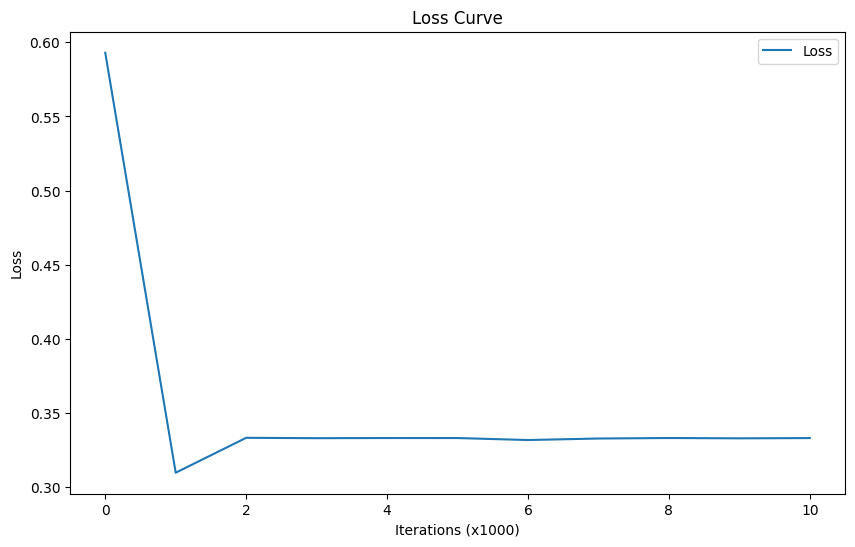

In [27]:
# Define the structure of the MLP
train_data, test_data, train_labels, X_train, X_test, y_train, y_test = prepare_flower_data()
layers = (c_int64 * 3)(X_train.shape[1],50, 3)  # Example structure with one hidden layer of 10 neurons
mlp_instance = create_mlp(layers, len(layers))
alpha =0.1
print("MLP network created with : ")
for i in range(len(layers)):
    print(layers[i],end=" ")
print("Alpha : ", alpha)

# Train the MLP network
try:
    train_mlp(mlp_instance, train_data, len(X_train), X_train.shape[1], train_labels, y_train.shape[1], alpha, 10000, True)
except Exception as e:
    print("Error during training:", e)

print("MLP network trained")

# Predict using the MLP network
def predict(mlp_instance, X):
    predictions = np.zeros((len(X), y_test.shape[1]), dtype=np.float64)
    for i in range(len(X)):
        test_sample = (c_double * X.shape[1])(*X[i])
        try:
            result_ptr = predict_mlp(mlp_instance, test_sample, 1, X.shape[1], True)
            if result_ptr:
                result_array = np.ctypeslib.as_array(result_ptr, shape=(1, y_test.shape[1]))
                predictions[i] = result_array
                mlp_lib.mlp_free(result_ptr)
            else:
                print(f"Error: result_ptr is NULL for sample {i}")
        except Exception as e:
            print(f"Error during prediction for sample {i}: {e}")
    return predictions

train_predictions = predict(mlp_instance, X_train)
test_predictions = predict(mlp_instance, X_test)

# Calculate accuracies
train_accuracy = accuracy_score(np.argmax(y_train, axis=1), np.argmax(train_predictions, axis=1))
test_accuracy = accuracy_score(np.argmax(y_test, axis=1), np.argmax(test_predictions, axis=1))

print(f"Train accuracy: {train_accuracy:.2f}")
print(f"Test accuracy: {test_accuracy:.2f}")
plot_loss_curve(mlp_instance)

#Encore underfitting

# AVEC 615 images par classe  et 2 couches caché de 128 et 64 et 10000 iteration et alpha = 0.1


Number of training points: 1492
Number of test points: 374
MLP network created with : 
9408 128 64 3 Alpha :  0.01
MLP network trained
Train accuracy: 0.56
Test accuracy: 0.56


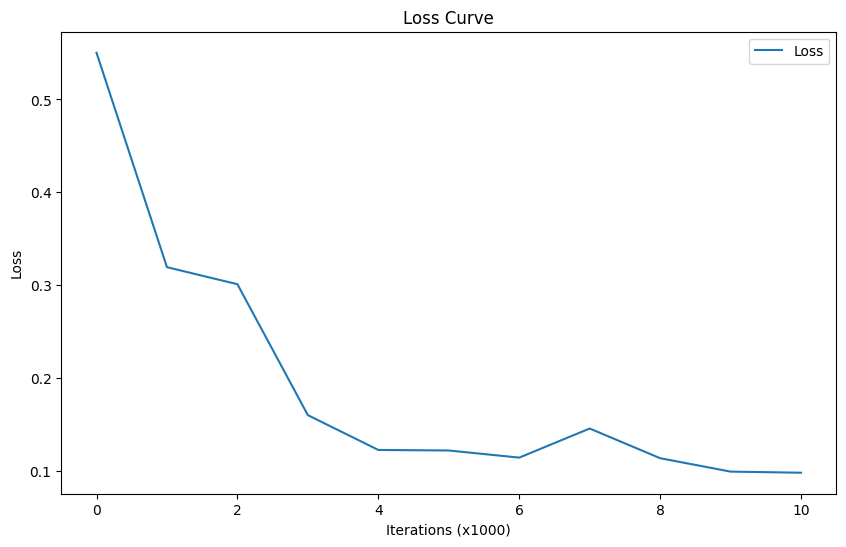

In [31]:
# Define the structure of the MLP
train_data, test_data, train_labels, X_train, X_test, y_train, y_test = prepare_flower_data()

layers = (c_int64 * 4)(X_train.shape[1],128 ,64, 3)  # Example structure with one hidden layer of 10 neurons
mlp_instance = create_mlp(layers, len(layers))
alpha=0.01
print("MLP network created with : ")
for i in range(len(layers)):
    print(layers[i],end=" ")
print("Alpha : ", alpha)

# Train the MLP network
try:
    train_mlp(mlp_instance, train_data, len(X_train), X_train.shape[1], train_labels, y_train.shape[1], alpha, 10000, True)
except Exception as e:
    print("Error during training:", e)

print("MLP network trained")

# Predict using the MLP network
def predict(mlp_instance, X):
    predictions = np.zeros((len(X), y_test.shape[1]), dtype=np.float64)
    for i in range(len(X)):
        test_sample = (c_double * X.shape[1])(*X[i])
        try:
            result_ptr = predict_mlp(mlp_instance, test_sample, 1, X.shape[1], True)
            if result_ptr:
                result_array = np.ctypeslib.as_array(result_ptr, shape=(1, y_test.shape[1]))
                predictions[i] = result_array
                mlp_lib.mlp_free(result_ptr)
            else:
                print(f"Error: result_ptr is NULL for sample {i}")
        except Exception as e:
            print(f"Error during prediction for sample {i}: {e}")
    return predictions

train_predictions = predict(mlp_instance, X_train)
test_predictions = predict(mlp_instance, X_test)

# Calculate accuracies
train_accuracy = accuracy_score(np.argmax(y_train, axis=1), np.argmax(train_predictions, axis=1))
test_accuracy = accuracy_score(np.argmax(y_test, axis=1), np.argmax(test_predictions, axis=1))

print(f"Train accuracy: {train_accuracy:.2f}")
print(f"Test accuracy: {test_accuracy:.2f}")
plot_loss_curve(mlp_instance)


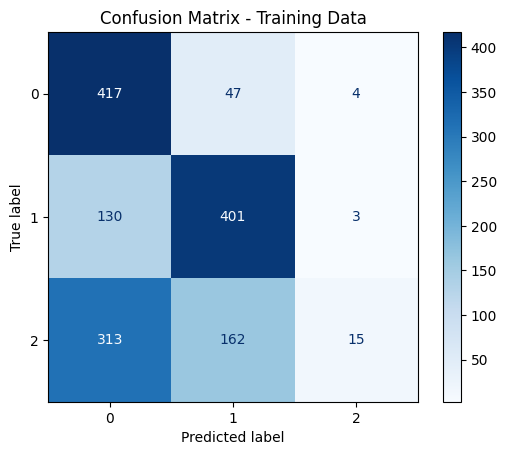

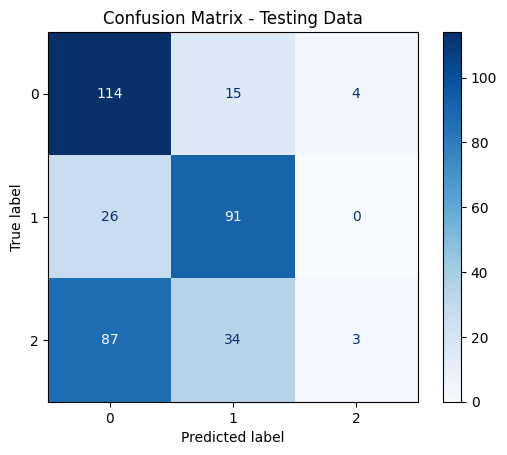

In [32]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Convert predictions to label indices
train_pred_indices = np.argmax(train_predictions, axis=1)
train_true_indices = np.argmax(y_train, axis=1)

test_pred_indices = np.argmax(test_predictions, axis=1)
test_true_indices = np.argmax(y_test, axis=1)

# Compute confusion matrices
cm_train = confusion_matrix(train_true_indices, train_pred_indices)
cm_test = confusion_matrix(test_true_indices, test_pred_indices)

# Plot confusion matrix for training data
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train)
disp_train.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Training Data')
plt.show()

# Plot confusion matrix for testing data
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test)
disp_test.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Testing Data')
plt.show()


In [11]:
train_data, test_data, train_labels, X_train, X_test, y_train, y_test = prepare_flower_data()

# Define the structure of the MLP
layers = (c_int64 * 3)(X_train.shape[1],100, 3)  # Example structure with one hidden layer of 10 neurons
mlp_instance = create_mlp(layers, len(layers))

print("MLP network created")
# Train the MLP network
try:
    train_mlp(mlp_instance, train_data, len(X_train), X_train.shape[1], train_labels, y_train.shape[1], 0.1, 10000, True)
except Exception as e:
    print("Error during training:", e)

print("MLP network trained")

# Predict using the MLP network
def predict(mlp_instance, X):
    predictions = np.zeros((len(X), y_test.shape[1]), dtype=np.float64)
    for i in range(len(X)):
        test_sample = (c_double * X.shape[1])(*X[i])
        try:
            result_ptr = predict_mlp(mlp_instance, test_sample, 1, X.shape[1], True)
            if result_ptr:
                result_array = np.ctypeslib.as_array(result_ptr, shape=(1, y_test.shape[1]))
                predictions[i] = result_array
                mlp_lib.mlp_free(result_ptr)
            else:
                print(f"Error: result_ptr is NULL for sample {i}")
        except Exception as e:
            print(f"Error during prediction for sample {i}: {e}")
    return predictions

train_predictions = predict(mlp_instance, X_train)
test_predictions = predict(mlp_instance, X_test)

# Calculate accuracies
train_accuracy = accuracy_score(np.argmax(y_train, axis=1), np.argmax(train_predictions, axis=1))
test_accuracy = accuracy_score(np.argmax(y_test, axis=1), np.argmax(test_predictions, axis=1))

print(f"Train accuracy: {train_accuracy:.2f}")
print(f"Test accuracy: {test_accuracy:.2f}")


Number of training points: 1492
Number of test points: 374
MLP network created
Training data shape: (1492, 9408)
Training labels shape: (1492, 3)
Flattened training data length: 14036736
Flattened training labels length: 4476
MLP network trained
Train accuracy: 0.61
Test accuracy: 0.62


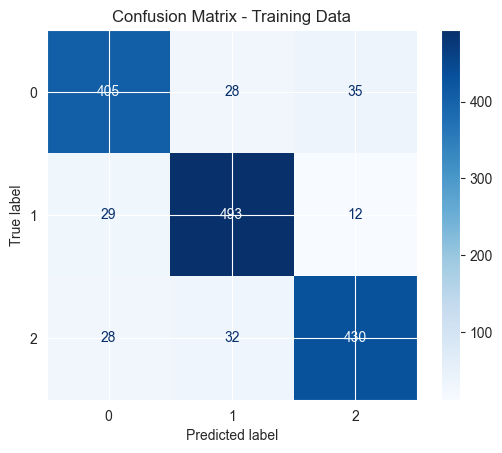

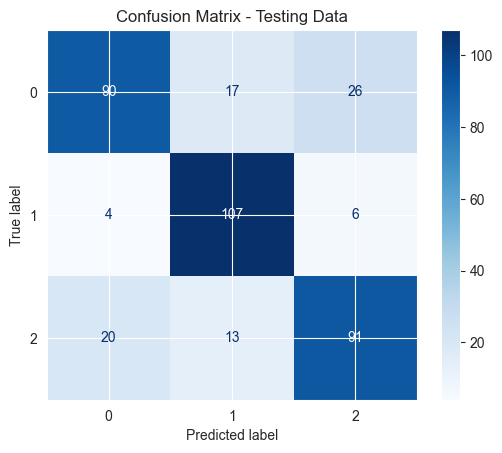

In [3]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib. pyplot as plt
# Convert predictions to label indices
train_pred_indices = np.argmax(train_predictions, axis=1)
train_true_indices = np.argmax(y_train, axis=1)

test_pred_indices = np.argmax(test_predictions, axis=1)
test_true_indices = np.argmax(y_test, axis=1)

# Compute confusion matrices
cm_train = confusion_matrix(train_true_indices, train_pred_indices)
cm_test = confusion_matrix(test_true_indices, test_pred_indices)

# Plot confusion matrix for training data
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train)
disp_train.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Training Data')
plt.show()

# Plot confusion matrix for testing data
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test)
disp_test.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Testing Data')
plt.show()


# Trouver les bon parametres du model 

In [6]:
train_data, test_data, train_labels, X_train, X_test, y_train, y_test = prepare_flower_data()

# Define the structure of the MLP
layers = (c_int64 * 3)(X_train.shape[1], 100, 3)  # Example structure with one hidden layer of 10 neurons

# Function to predict using the MLP network
def predict(mlp_instance, X):
    predictions = np.zeros((len(X), y_test.shape[1]), dtype=np.float64)
    for i in range(len(X)):
        test_sample = (c_double * X.shape[1])(*X[i])
        try:
            result_ptr = predict_mlp(mlp_instance, test_sample, 1, X.shape[1], True)
            if result_ptr:
                result_array = np.ctypeslib.as_array(result_ptr, shape=(1, y_test.shape[1]))
                predictions[i] = result_array
                mlp_lib.mlp_free(result_ptr)
            else:
                print(f"Error: result_ptr is NULL for sample {i}")
        except Exception as e:
            print(f"Error during prediction for sample {i}: {e}")
    return predictions

alpha_values = [0.1, 0.01, 0.001, 0.05,0.0001]

results = {}

for alpha in alpha_values:
    # Créer une nouvelle instance de MLP pour chaque alpha.
    mlp_instance = create_mlp(layers, len(layers))
    # Entraîner le réseau MLP.
    try:
        train_mlp(mlp_instance, train_data, len(X_train), X_train.shape[1], train_labels, y_train.shape[1], alpha, 10000, True)
        print(f"MLP network trained with alpha = {alpha}")
    except Exception as e:
        print(f"Error during training with alpha = {alpha}: {e}")
        continue
    # Predict on training and testing sets
    train_predictions = predict(mlp_instance, X_train)
    test_predictions = predict(mlp_instance, X_test)

    # Calculate accuracies
    train_accuracy = accuracy_score(np.argmax(y_train, axis=1), np.argmax(train_predictions, axis=1))
    test_accuracy = accuracy_score(np.argmax(y_test, axis=1), np.argmax(test_predictions, axis=1))

    # Store the results
    results[alpha] = {
        "Train accuracy": train_accuracy,
        "Test accuracy": test_accuracy
    }

    # Destroy the MLP instance to free up memory
    destroy_mlp(mlp_instance)

# Print results
for alpha, result in results.items():
    print(f"For alpha = {alpha}:")
    print(f"  Train accuracy: {result['Train accuracy']:.2f}")
    print(f"  Test accuracy: {result['Test accuracy']:.2f}")


Number of training points: 1492
Number of test points: 374
MLP network trained with alpha = 0.1
MLP network trained with alpha = 0.01
MLP network trained with alpha = 0.001
MLP network trained with alpha = 0.05
MLP network trained with alpha = 0.0001
For alpha = 0.1:
  Train accuracy: 0.35
  Test accuracy: 0.35
For alpha = 0.01:
  Train accuracy: 0.56
  Test accuracy: 0.51
For alpha = 0.001:
  Train accuracy: 0.37
  Test accuracy: 0.35
For alpha = 0.05:
  Train accuracy: 0.37
  Test accuracy: 0.31
For alpha = 0.0001:
  Train accuracy: 0.36
  Test accuracy: 0.33


In [8]:
train_data, test_data, train_labels, X_train, X_test, y_train, y_test = prepare_flower_data()

# Function to predict using the MLP network
def predict(mlp_instance, X):
    predictions = np.zeros((len(X), y_test.shape[1]), dtype=np.float64)
    for i in range(len(X)):
        test_sample = (c_double * X.shape[1])(*X[i])
        try:
            result_ptr = predict_mlp(mlp_instance, test_sample, 1, X.shape[1], True)
            if result_ptr:
                result_array = np.ctypeslib.as_array(result_ptr, shape=(1, y_test.shape[1]))
                predictions[i] = result_array
                mlp_lib.mlp_free(result_ptr)
            else:
                print(f"Error: result_ptr is NULL for sample {i}")
        except Exception as e:
            print(f"Error during prediction for sample {i}: {e}")
    return predictions
# List des structures du mlp 
mlp_structures = [
    [X_train.shape[1], 16, 3],          
    [X_train.shape[1], 64, 3],          
    [X_train.shape[1], 32, 16, 3],      
    [X_train.shape[1], 64, 32, 3],      
    [X_train.shape[1], 90,45,3],
    [X_train.shape[1], 128,64,3],
    [X_train.shape[1], 32, 16, 8, 3],   
    [X_train.shape[1], 64, 32, 16, 3]   
]

# Dictionnaire pour stocker les résultats

results = {}
alpha = 0.01

for structure in mlp_structures:
    # Définir la structure du MLP
    layers = (c_int64 * len(structure))(*structure)
    mlp_instance = create_mlp(layers, len(layers))
    try:
        train_mlp(mlp_instance, train_data, len(X_train), X_train.shape[1], train_labels, y_train.shape[1], alpha, 10000, True)
        print(f"MLP network trained with structure = {structure}")
    except Exception as e:
        print(f"Error during training with structure = {structure}: {e}")
        continue

    # Predict on training and testing sets
    train_predictions = predict(mlp_instance, X_train)
    test_predictions = predict(mlp_instance, X_test)

    # Calculate accuracies
    train_accuracy = accuracy_score(np.argmax(y_train, axis=1), np.argmax(train_predictions, axis=1))
    test_accuracy = accuracy_score(np.argmax(y_test, axis=1), np.argmax(test_predictions, axis=1))

    # Store the results
    results[tuple(structure)] = {
        "Train accuracy": train_accuracy,
        "Test accuracy": test_accuracy
    }

    # Destroy the MLP instance to free up memory
    destroy_mlp(mlp_instance)

# Print results
for structure, result in results.items():
    print(f"For structure = {structure}:")
    print(f"  Train accuracy: {result['Train accuracy']:.2f}")
    print(f"  Test accuracy: {result['Test accuracy']:.2f}")


Number of training points: 3834
Number of test points: 959
MLP network trained with structure = [9408, 16, 3]
MLP network trained with structure = [9408, 64, 3]
MLP network trained with structure = [9408, 32, 16, 3]
MLP network trained with structure = [9408, 64, 32, 3]
MLP network trained with structure = [9408, 90, 45, 3]
MLP network trained with structure = [9408, 128, 64, 3]
MLP network trained with structure = [9408, 32, 16, 8, 3]
MLP network trained with structure = [9408, 64, 32, 16, 3]
For structure = (9408, 16, 3):
  Train accuracy: 0.46
  Test accuracy: 0.48
For structure = (9408, 64, 3):
  Train accuracy: 0.46
  Test accuracy: 0.45
For structure = (9408, 32, 16, 3):
  Train accuracy: 0.65
  Test accuracy: 0.64
For structure = (9408, 64, 32, 3):
  Train accuracy: 0.59
  Test accuracy: 0.60
For structure = (9408, 90, 45, 3):
  Train accuracy: 0.57
  Test accuracy: 0.58
For structure = (9408, 128, 64, 3):
  Train accuracy: 0.48
  Test accuracy: 0.52
For structure = (9408, 32, 1

In [21]:
train_data, test_data, train_labels, X_train, X_test, y_train, y_test = prepare_flower_data()

layers = (c_int64 * 4)(X_train.shape[1],90,45, 3)  # Example structure with one hidden layer of 10 neurons
mlp_instance = create_mlp(layers, len(layers))

print("MLP network created")

# Print debug information for the arguments passed to train_mlp
print("Training data shape:", X_train.shape)
print("Training labels shape:", y_train.shape)
print("Flattened training data length:", len(train_data))
print("Flattened training labels length:", len(train_labels))

# Train the MLP network
try:
    train_mlp(mlp_instance, train_data, len(X_train), X_train.shape[1], train_labels, y_train.shape[1], 0.01, 300000, True)
except Exception as e:
    print("Error during training:", e)

print("MLP network trained")

# Predict using the MLP network
def predict(mlp_instance, X):
    predictions = np.zeros((len(X), y_test.shape[1]), dtype=np.float64)
    for i in range(len(X)):
        test_sample = (c_double * X.shape[1])(*X[i])
        try:
            result_ptr = predict_mlp(mlp_instance, test_sample, 1, X.shape[1], True)
            if result_ptr:
                result_array = np.ctypeslib.as_array(result_ptr, shape=(1, y_test.shape[1]))
                predictions[i] = result_array
                mlp_lib.mlp_free(result_ptr)
            else:
                print(f"Error: result_ptr is NULL for sample {i}")
        except Exception as e:
            print(f"Error during prediction for sample {i}: {e}")
    return predictions

train_predictions = predict(mlp_instance, X_train)
test_predictions = predict(mlp_instance, X_test)

# Calculate accuracies
train_accuracy = accuracy_score(np.argmax(y_train, axis=1), np.argmax(train_predictions, axis=1))
test_accuracy = accuracy_score(np.argmax(y_test, axis=1), np.argmax(test_predictions, axis=1))

print(f"Train accuracy: {train_accuracy:.2f}")
print(f"Test accuracy: {test_accuracy:.2f}")


Number of training points: 3834
Number of test points: 959
MLP network created
Training data shape: (3834, 9408)
Training labels shape: (3834, 3)
Flattened training data length: 36070272
Flattened training labels length: 11502
MLP network trained
Train accuracy: 0.83
Test accuracy: 0.82


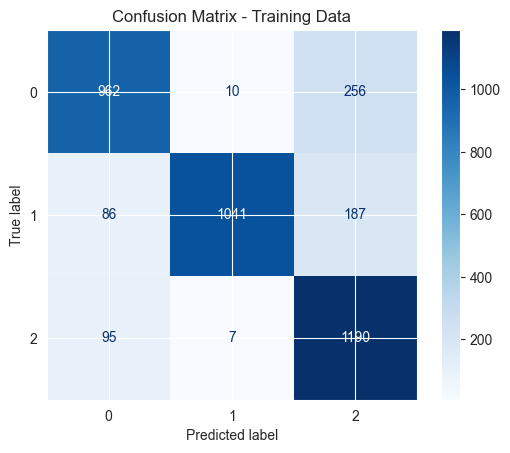

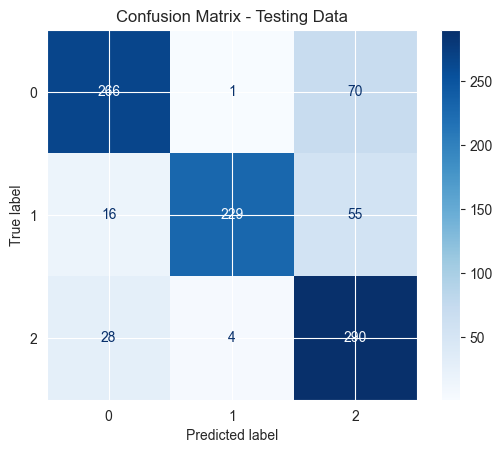

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Convert predictions to label indices
train_pred_indices = np.argmax(train_predictions, axis=1)
train_true_indices = np.argmax(y_train, axis=1)

test_pred_indices = np.argmax(test_predictions, axis=1)
test_true_indices = np.argmax(y_test, axis=1)

# Compute confusion matrices
cm_train = confusion_matrix(train_true_indices, train_pred_indices)
cm_test = confusion_matrix(test_true_indices, test_pred_indices)

# Plot confusion matrix for training data
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train)
disp_train.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Training Data')
plt.show()

# Plot confusion matrix for testing data
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test)
disp_test.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Testing Data')
plt.show()


# Entrainer et sauvgarder le model avec les bon parametres

Number of training points: 3834
Number of test points: 959
MLP network created
MLP network created with : 
9408 32 16 3 Alpha :  0.01
MLP network trained
MLP model saved
MLP model loaded
Train accuracy: 0.90
Test accuracy: 0.88


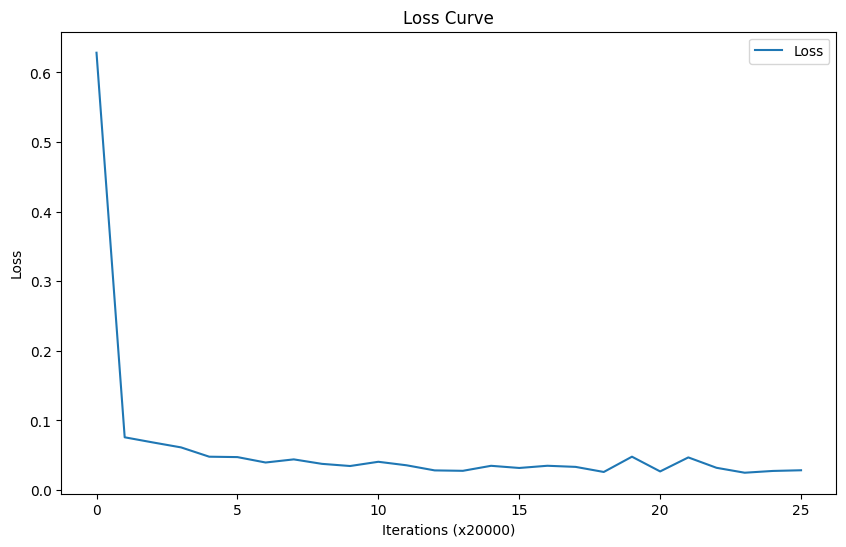

In [4]:
train_data, test_data, train_labels, X_train, X_test, y_train, y_test = prepare_flower_data()

# Define the structure of the MLP
layers = (c_int64 * 4)(X_train.shape[1], 32, 16, 3)  
mlp_instance = create_mlp(layers, len(layers))

print("MLP network created")

alpha = 0.01
print("MLP network created with : ")
for i in range(len(layers)):
    print(layers[i], end=" ")
print("Alpha : ", alpha)

# Train the MLP network
try:
    train_mlp(mlp_instance, train_data, len(X_train), X_train.shape[1], train_labels, y_train.shape[1], alpha, 800000, True)
except Exception as e:
    print("Error during training:", e)

print("MLP network trained")

# Save the trained model
save_mlp(mlp_instance, b'C:/Users/webazza/Desktop/Projet_annual/PA_Pycha/loaded_lib/mon_mlp_model.bin')
print("MLP model saved")

# Load the trained model
load_mlp(mlp_instance, b'C:/Users/webazza/Desktop/Projet_annual/PA_Pycha/loaded_lib/mon_mlp_model.bin')
print("MLP model loaded")

# Predict using the MLP network
def predict(mlp_instance, X):
    predictions = np.zeros((len(X), y_test.shape[1]), dtype=np.float64)
    for i in range(len(X)):
        test_sample = (c_double * X.shape[1])(*X[i])
        try:
            result_ptr = predict_mlp(mlp_instance, test_sample, 1, X.shape[1], True)
            if result_ptr:
                result_array = np.ctypeslib.as_array(result_ptr, shape=(1, y_test.shape[1]))
                predictions[i] = result_array
                mlp_lib.mlp_free(result_ptr)
            else:
                print(f"Error: result_ptr is NULL for sample {i}")
        except Exception as e:
            print(f"Error during prediction for sample {i}: {e}")
    return predictions

train_predictions = predict(mlp_instance, X_train)
test_predictions = predict(mlp_instance, X_test)

# Calculate accuracies
train_accuracy = accuracy_score(np.argmax(y_train, axis=1), np.argmax(train_predictions, axis=1))
test_accuracy = accuracy_score(np.argmax(y_test, axis=1), np.argmax(test_predictions, axis=1))

print(f"Train accuracy: {train_accuracy:.2f}")
print(f"Test accuracy: {test_accuracy:.2f}")

plot_loss_curve(mlp_instance)

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
# Convert predictions to label indices
train_pred_indices = np.argmax(train_predictions, axis=1)
train_true_indices = np.argmax(y_train, axis=1)

test_pred_indices = np.argmax(test_predictions, axis=1)
test_true_indices = np.argmax(y_test, axis=1)

# Compute confusion matrices
cm_train = confusion_matrix(train_true_indices, train_pred_indices)
cm_test = confusion_matrix(test_true_indices, test_pred_indices)

# Plot confusion matrix for training data
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train)
disp_train.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Training Data')
plt.show()

# Plot confusion matrix for testing data
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test)
disp_test.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Testing Data')
plt.show()
